# diag_paris_tegmark — where is *spatial* (place) information stored?

Replicates the linear-probe method of **Gurnee & Tegmark (2024), "Language Models Represent Space and Time"** (they used Llama-2 / Pythia) on **Llama-3.1-8B-Instruct**.

**Method:** feed each city name, take the last-token residual stream at every layer, and train a per-layer linear (Ridge) probe to predict the city's (latitude, longitude). The layer where lat/lon becomes most linearly decodable is where the model has built an explicit spatial representation. We then check **Paris** by leave-one-out prediction.

This tells us *where in depth* the model holds geographic position — i.e. one component of what 'Paris' is.

In [1]:
import torch, numpy as np, os
from transformers import AutoModelForCausalLM, AutoTokenizer
os.makedirs("plots", exist_ok=True)

MODEL_ID = "meta-llama/Meta-Llama-3.1-8B-Instruct"   # same Instruct model used in the steering experiments
device = torch.device("mps" if torch.backends.mps.is_available()
                      else ("cuda" if torch.cuda.is_available() else "cpu"))
dtype  = torch.float16 if device.type != "cpu" else torch.float32
print("device:", device, "| dtype:", dtype)

tok = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype=dtype).to(device).eval()
NL = model.config.num_hidden_layers
D  = model.config.hidden_size
print("layers:", NL, "| d_model:", D)

device: mps | dtype: torch.float16


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

layers: 32 | d_model: 4096


## 1. City coordinates (ground truth)

In [2]:
CITIES = {
  "Paris":(48.85,2.35),"London":(51.51,-0.13),"Berlin":(52.52,13.40),"Madrid":(40.42,-3.70),
  "Rome":(41.90,12.50),"Lisbon":(38.72,-9.14),"Amsterdam":(52.37,4.90),"Brussels":(50.85,4.35),
  "Vienna":(48.21,16.37),"Zurich":(47.37,8.54),"Geneva":(46.20,6.14),"Munich":(48.14,11.58),
  "Milan":(45.46,9.19),"Barcelona":(41.39,2.17),"Athens":(37.98,23.73),"Dublin":(53.35,-6.26),
  "Edinburgh":(55.95,-3.19),"Stockholm":(59.33,18.07),"Oslo":(59.91,10.75),"Copenhagen":(55.68,12.57),
  "Helsinki":(60.17,24.94),"Warsaw":(52.23,21.01),"Prague":(50.08,14.44),"Budapest":(47.50,19.04),
  "Moscow":(55.76,37.62),"Istanbul":(41.01,28.98),"New York":(40.71,-74.01),"Los Angeles":(34.05,-118.24),
  "Chicago":(41.88,-87.63),"Houston":(29.76,-95.37),"Boston":(42.36,-71.06),"Seattle":(47.61,-122.33),
  "San Francisco":(37.77,-122.42),"Miami":(25.76,-80.19),"Denver":(39.74,-104.99),"Atlanta":(33.75,-84.39),
  "Dallas":(32.78,-96.80),"Washington":(38.91,-77.04),"Toronto":(43.65,-79.38),"Montreal":(45.50,-73.57),
  "Vancouver":(49.28,-123.12),"Mexico City":(19.43,-99.13),"Buenos Aires":(-34.60,-58.38),
  "Sao Paulo":(-23.55,-46.63),"Rio de Janeiro":(-22.91,-43.17),"Lima":(-12.05,-77.04),
  "Bogota":(4.71,-74.07),"Santiago":(-33.45,-70.67),"Cairo":(30.04,31.24),"Lagos":(6.52,3.38),
  "Nairobi":(-1.29,36.82),"Johannesburg":(-26.20,28.05),"Cape Town":(-33.92,18.42),
  "Casablanca":(33.57,-7.59),"Accra":(5.60,-0.19),"Addis Ababa":(9.03,38.74),"Dubai":(25.20,55.27),
  "Riyadh":(24.71,46.68),"Tehran":(35.69,51.39),"Baghdad":(33.31,44.36),"Jerusalem":(31.77,35.21),
  "Mumbai":(19.08,72.88),"Delhi":(28.61,77.21),"Bangalore":(12.97,77.59),"Kolkata":(22.57,88.36),
  "Karachi":(24.86,67.01),"Dhaka":(23.81,90.41),"Bangkok":(13.76,100.50),"Jakarta":(-6.21,106.85),
  "Singapore":(1.35,103.82),"Kuala Lumpur":(3.14,101.69),"Manila":(14.60,120.98),"Hanoi":(21.03,105.85),
  "Beijing":(39.90,116.41),"Shanghai":(31.23,121.47),"Hong Kong":(22.32,114.17),"Guangzhou":(23.13,113.26),
  "Tokyo":(35.68,139.69),"Osaka":(34.69,135.50),"Seoul":(37.57,126.98),"Taipei":(25.03,121.57),
  "Sydney":(-33.87,151.21),"Melbourne":(-37.81,144.96),"Brisbane":(-27.47,153.03),"Perth":(-31.95,115.86),
  "Auckland":(-36.85,174.76),"Wellington":(-41.29,174.78),"Honolulu":(21.31,-157.86),
  "Anchorage":(61.22,-149.90),"Reykjavik":(64.15,-21.94),
}
print(len(CITIES), "cities; Paris included:", "Paris" in CITIES)

90 cities; Paris included: True


## 2. Extract last-token residual at every layer

In [3]:
@torch.no_grad()
def last_token_hidden(text):
    ids = tok(text, return_tensors="pt").to(device)
    out = model(**ids, output_hidden_states=True)
    # hidden_states: tuple len NL+1 (0 = embeddings). Take last token of each.
    hs = torch.stack(out.hidden_states, 0)[:, 0, -1, :]   # (NL+1, D)
    return hs.float().cpu().numpy()

names = list(CITIES)
X = np.stack([last_token_hidden(c) for c in names])       # (n, NL+1, D)
Y = np.array([CITIES[c] for c in names], dtype=float)     # (n, 2) = lat, lon
print("activations:", X.shape, "| targets:", Y.shape)

activations: (90, 33, 4096) | targets: (90, 2)


## 3. Per-layer lat/lon probe (5-fold CV)

In [4]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

def haversine(a, b):
    R=6371.0
    la1,lo1,la2,lo2 = map(np.radians, [a[:,0],a[:,1],b[:,0],b[:,1]])
    h = np.sin((la2-la1)/2)**2 + np.cos(la1)*np.cos(la2)*np.sin((lo2-lo1)/2)**2
    return 2*R*np.arcsin(np.sqrt(h))

kf = KFold(5, shuffle=True, random_state=0)
r2s, errs = [], []
for L in range(X.shape[1]):
    XL = X[:, L, :]; preds = np.zeros_like(Y)
    for tr, te in kf.split(XL):
        sc = StandardScaler().fit(XL[tr])
        m  = Ridge(alpha=1000.0).fit(sc.transform(XL[tr]), Y[tr])
        preds[te] = m.predict(sc.transform(XL[te]))
    r2s.append(r2_score(Y, preds)); errs.append(np.median(haversine(Y, preds)))
r2s, errs = np.array(r2s), np.array(errs)
best = int(np.argmax(r2s))
print(f"best layer (hidden_states idx {best}, ~block {best-1}): R2={r2s[best]:.3f}, median err={errs[best]:.0f} km")

best layer (hidden_states idx 7, ~block 6): R2=0.715, median err=2876 km


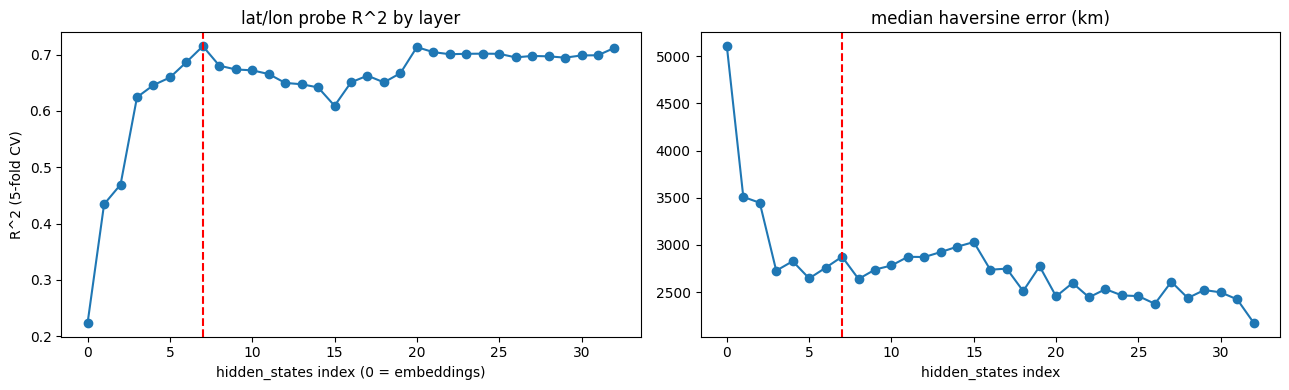

In [5]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(range(len(r2s)), r2s, "o-"); ax[0].axvline(best, color="r", ls="--")
ax[0].set_title("lat/lon probe R^2 by layer"); ax[0].set_xlabel("hidden_states index (0 = embeddings)"); ax[0].set_ylabel("R^2 (5-fold CV)")
ax[1].plot(range(len(errs)), errs, "o-"); ax[1].axvline(best, color="r", ls="--")
ax[1].set_title("median haversine error (km)"); ax[1].set_xlabel("hidden_states index")
plt.tight_layout(); plt.savefig("plots/diag_paris_tegmark_probe.png", dpi=120); plt.show()

## 4. Locate Paris (leave-one-out at the best layer)

In [6]:
i = names.index("Paris")
XL = X[:, best, :]; mask = np.arange(len(names)) != i
sc = StandardScaler().fit(XL[mask]); m = Ridge(alpha=1000.0).fit(sc.transform(XL[mask]), Y[mask])
pred = m.predict(sc.transform(XL[i:i+1]))[0]
err  = haversine(Y[i:i+1], pred[None])[0]
print(f"Paris  actual (lat,lon) = {tuple(Y[i])}")
print(f"Paris  predicted        = ({pred[0]:.2f}, {pred[1]:.2f})   error = {err:.0f} km")
# nearest cities to Paris in activation space at the best layer
d = np.linalg.norm(XL - XL[i], axis=1); order = np.argsort(d)
print("\nnearest cities to Paris in layer activations:", [names[j] for j in order[1:6]])

Paris  actual (lat,lon) = (np.float64(48.85), np.float64(2.35))
Paris  predicted        = (47.36, -8.42)   error = 816 km

nearest cities to Paris in layer activations: ['London', 'Berlin', 'Madrid', 'Amsterdam', 'Rome']


## Reading this
- The R² curve shows **which depth** holds geographic position. Gurnee & Tegmark found spatial features emerge and peak in the **mid-to-late** layers; compare the peak `best` layer here.
- A low Paris leave-one-out error means the model places Paris correctly on a learned world map at that layer — i.e. the *spatial* coordinate of Paris is linearly present, even if it isn't the direction RFM steering picks up. Note hidden_states index `k` ≈ output of block `k-1`.